In [19]:
# Cell 1: System Dependencies, Setup & The FRAE-S Engine
!apt-get update -qy && apt-get install -qy swig
!pip install -q "gymnasium[box2d]"

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt

# Enforce hardware acceleration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"FRAE-S Kinetic Engine Initialized on: {device}")

def compute_fraes_advantages(rewards, values, dones, gamma=0.99, alpha=0.01, re_crit=2.0, beta_laminar=0.95, eps=1e-8):
    """
    Computes the FRAE-S governed by the Information Reynolds Number.
    Assumes 1D tensors of shape (T,) for a single continuous trajectory.
    """
    T = rewards.shape[0]

    # 1. Raw Temporal Difference Errors (The Input Energy)
    deltas = rewards + gamma * values[1:] * (1 - dones) - values[:-1]

    zetas = torch.zeros_like(deltas)
    betas = torch.zeros_like(deltas)
    re_infos = torch.zeros_like(deltas)

    # 2. Forward Pass: Causal Sensor Phase
    current_var = torch.tensor(eps, device=device)
    prev_delta = torch.tensor(0.0, device=device)

    for t in range(T):
        # Kinetic Energy of the TD-Error (Variance EMA)
        current_var = (1 - alpha) * current_var + alpha * (deltas[t] ** 2)
        zeta_t = torch.sqrt(current_var) + eps
        zetas[t] = zeta_t

        # Information Reynolds Number (Inertial Momentum / Viscous Stability)
        momentum = torch.abs(deltas[t] - prev_delta)
        re_info = momentum / zeta_t
        re_infos[t] = re_info

        # Navier-Stokes Phase Transition Switch: Exponential Hysteresis
        decay_factor = torch.exp(- (re_info / re_crit)**2 )
        betas[t] = beta_laminar * decay_factor

        prev_delta = deltas[t]

    # 3. Backward Pass: Fluid Advantage Energy Flow
    advantages = torch.zeros_like(deltas)
    U_next = torch.tensor(0.0, device=device)

    for t in reversed(range(T)):
        # U_t = δ_t + γ * β_t * U_{t+1}
        U_t = deltas[t] + gamma * betas[t] * (1 - dones[t]) * U_next

        # Apply the Fierce Stability Sink
        advantages[t] = U_t / zetas[t]

        U_next = U_t

    return advantages, betas, zetas, re_infos

Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Get:3 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Fetched 129 kB in 1s (94.3 kB/s)
Reading package lists...
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists...
Building dependency tree...
Reading state information...
swig is already the newest version (4.0.2-1ubuntu1).
0 upgraded, 0 newly

In [20]:
# Cell 2: Actor-Critic Architecture & Fluid Rollout Buffer
class A2CNetwork(nn.Module):
    def __init__(self, obs_dim, action_dim, hidden_size=64):
        super(A2CNetwork, self).__init__()
        self.actor = nn.Sequential(
            nn.Linear(obs_dim, hidden_size), nn.Tanh(),
            nn.Linear(hidden_size, hidden_size), nn.Tanh(),
            nn.Linear(hidden_size, action_dim)
        )
        self.critic = nn.Sequential(
            nn.Linear(obs_dim, hidden_size), nn.Tanh(),
            nn.Linear(hidden_size, hidden_size), nn.Tanh(),
            nn.Linear(hidden_size, 1)
        )

    def forward(self, x):
        return self.actor(x), self.critic(x)

    def get_action_and_value(self, x, action=None):
        logits = self.actor(x)
        probs = torch.distributions.Categorical(logits=logits)
        if action is None: action = probs.sample()
        return action, probs.log_prob(action), probs.entropy(), self.critic(x)

class FluidRolloutBuffer:
    def __init__(self, num_steps, obs_dim, device):
        self.num_steps = num_steps
        self.device = device
        self.obs = torch.zeros((num_steps, obs_dim), dtype=torch.float32).to(device)
        self.actions = torch.zeros((num_steps,), dtype=torch.float32).to(device)
        self.logprobs = torch.zeros((num_steps,), dtype=torch.float32).to(device)
        self.rewards = torch.zeros((num_steps,), dtype=torch.float32).to(device)
        self.dones = torch.zeros((num_steps,), dtype=torch.float32).to(device)
        self.values = torch.zeros((num_steps,), dtype=torch.float32).to(device)
        self.entropies = torch.zeros((num_steps,), dtype=torch.float32).to(device)
        self.step = 0

    def add(self, obs, action, logprob, reward, done, value, entropy):
        self.obs[self.step] = obs
        self.actions[self.step] = action
        self.logprobs[self.step] = logprob
        self.rewards[self.step] = reward
        self.dones[self.step] = done
        self.values[self.step] = value
        self.entropies[self.step] = entropy
        self.step += 1

    def compute_returns_and_advantages(self, next_value, done_flag, gamma=0.99, alpha=0.01, re_crit=2.0, beta_laminar=0.95, eps=1e-8):
        full_values = torch.cat([self.values, next_value.view(-1)]).to(self.device)
        advantages, betas, zetas, re_infos = compute_fraes_advantages(
            rewards=self.rewards, values=full_values, dones=self.dones,
            gamma=gamma, alpha=alpha, re_crit=re_crit, beta_laminar=beta_laminar, eps=eps
        )
        returns = advantages + self.values
        self.step = 0
        return returns, advantages, betas, zetas, re_infos

In [21]:
# Cell 3: Topological Calibration & Main Training Loop
def calibrate_environment(env_name, probe_steps=5000, gamma=0.99):
    print(f"Initiating Topological Probe on {env_name}...")
    env = gym.make(env_name)
    network = A2CNetwork(env.observation_space.shape[0], env.action_space.n).to(device)
    rewards, values = [], []
    obs, _ = env.reset()

    for _ in range(probe_steps):
        obs_tensor = torch.tensor(obs, dtype=torch.float32).to(device)
        with torch.no_grad():
            action, _, _, value = network.get_action_and_value(obs_tensor)
        next_obs, reward, terminated, truncated, _ = env.step(action.item())
        rewards.append(reward)
        values.append(value.item())
        obs = env.reset()[0] if terminated or truncated else next_obs
    env.close()

    rewards, values = np.array(rewards), np.array(values)
    reward_variance = np.var(rewards)

    if reward_variance < 1e-4:
        optimal_entropy_coef = 0.05
        print("Topology: SPARSE. Forcing high thermodynamic exploration.")
    else:
        optimal_entropy_coef = 0.005
        print("Topology: DENSE. Engaging precision gradient tracking.")

    deltas = rewards[:-1] + gamma * values[1:] - values[:-1]
    optimal_eps = max(np.std(deltas), 1e-4)
    momentums = np.abs(np.diff(deltas))
    optimal_re_crit = max(np.percentile(momentums, 95) / optimal_eps, 1.5)

    print("-" * 40)
    print("100% Precision Calibration Complete:")
    print(f"-> Optimal Entropy Coef: {optimal_entropy_coef:.4f}")
    print(f"-> Optimal Viscosity Floor (eps): {optimal_eps:.4f}")
    print(f"-> Optimal Re_crit (95th %ile): {optimal_re_crit:.4f}")
    print("-" * 40)
    return optimal_entropy_coef, optimal_eps, optimal_re_crit

def train_fraes_agent(env_name="LunarLander-v3", total_epochs=1000, steps_per_epoch=500, opt_entropy=0.01, opt_eps=1e-8, opt_re=2.0):
    env = gym.make(env_name)
    network = A2CNetwork(env.observation_space.shape[0], env.action_space.n).to(device)
    optimizer = optim.Adam(network.parameters(), lr=0.001)
    buffer = FluidRolloutBuffer(steps_per_epoch, env.observation_space.shape[0], device)

    history = {'rewards': [], 'policy_loss': [], 'value_loss': [], 'mean_beta': [], 'mean_zeta': [], 'max_re_info': []}
    obs, _ = env.reset()

    for epoch in range(total_epochs):
        epoch_reward = 0
        for step in range(steps_per_epoch):
            obs_tensor = torch.tensor(obs, dtype=torch.float32).to(device)
            with torch.no_grad():
                action, logprob, entropy, value = network.get_action_and_value(obs_tensor)
            next_obs, reward, terminated, truncated, _ = env.step(action.item())
            done = terminated or truncated
            epoch_reward += reward
            buffer.add(obs_tensor, action, logprob, reward, done, value.squeeze(), entropy)
            obs = env.reset()[0] if done else next_obs

        next_obs_tensor = torch.tensor(obs, dtype=torch.float32).to(device)
        with torch.no_grad():
            _, _, _, next_value = network.get_action_and_value(next_obs_tensor)

        returns, advantages, betas, zetas, re_infos = buffer.compute_returns_and_advantages(
            next_value.squeeze(), done_flag=done, gamma=0.99, alpha=0.01, re_crit=opt_re, beta_laminar=0.95, eps=opt_eps
        )

        _, logprobs, entropies, values = network.get_action_and_value(buffer.obs, buffer.actions)
        values = values.squeeze()

        policy_loss = -(logprobs * advantages).mean()
        value_loss = torch.nn.functional.smooth_l1_loss(values, returns)
        entropy_loss = -opt_entropy * entropies.mean()

        loss = policy_loss + value_loss + entropy_loss
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(network.parameters(), max_norm=0.5)
        optimizer.step()

        history['rewards'].append(epoch_reward)
        history['policy_loss'].append(policy_loss.item())
        history['value_loss'].append(value_loss.item())
        history['mean_beta'].append(betas.mean().item())
        history['mean_zeta'].append(zetas.mean().item())
        history['max_re_info'].append(re_infos.max().item())

        if (epoch + 1) % 50 == 0:
            print(f"Epoch {epoch+1:03d} | Reward: {epoch_reward:03.1f} | Re_max: {re_infos.max().item():.2f} | Zeta: {zetas.mean().item():.3f} | Beta: {betas.mean().item():.2f}")

    env.close()
    return network, history

In [22]:
# Cell 4: Physics-Informed Telemetry Visualization
def plot_fraes_telemetry(history):
    epochs = np.arange(len(history['rewards']))
    fig, axs = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle("FRAE-S Navier-Stokes Internal Telemetry", fontsize=16, fontweight='bold')

    axs[0, 0].plot(epochs, history['rewards'], color='blue', alpha=0.8, linewidth=2)
    axs[0, 0].set_title("Episodic Reward Capacity")
    axs[0, 0].set_xlabel("Epochs")
    axs[0, 0].set_ylabel("Reward")
    axs[0, 0].grid(True, alpha=0.3)

    axs[0, 1].plot(epochs, history['policy_loss'], label="Policy Loss", color='purple')
    axs[0, 1].plot(epochs, history['value_loss'], label="Value Loss", color='orange')
    axs[0, 1].set_title("Network Convergence Losses")
    axs[0, 1].set_xlabel("Epochs")
    axs[0, 1].set_ylabel("Loss Magnitude")
    axs[0, 1].legend()
    axs[0, 1].grid(True, alpha=0.3)

    axs[1, 0].plot(epochs, history['mean_beta'], color='cyan', linewidth=2)
    axs[1, 0].set_title("Mean Liquid Horizon (β_t)")
    axs[1, 0].set_xlabel("Epochs")
    axs[1, 0].set_ylabel("Horizon Elasticity (0 to 1)")
    axs[1, 0].grid(True, alpha=0.3)

    ax4_twin = axs[1, 1].twinx()
    l1 = axs[1, 1].plot(epochs, history['mean_zeta'], color='green', label="Viscosity Invariant (ζ_t)", linewidth=2)
    l2 = ax4_twin.plot(epochs, history['max_re_info'], color='red', alpha=0.5, label="Max Reynolds Info (Re)", linestyle='--')
    axs[1, 1].set_title("Kinetic Stability vs. Information Momentum")
    axs[1, 1].set_xlabel("Epochs")
    axs[1, 1].set_ylabel("Viscosity / Variance Scale", color='green')
    ax4_twin.set_ylabel("Reynolds Information Momentum", color='red')

    lns = l1 + l2
    labs = [l.get_label() for l in lns]
    axs[1, 1].legend(lns, labs, loc='upper left')
    axs[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.show()

Initiating Topological Probe on LunarLander-v3...
Topology: DENSE. Engaging precision gradient tracking.
----------------------------------------
100% Precision Calibration Complete:
-> Optimal Entropy Coef: 0.0050
-> Optimal Viscosity Floor (eps): 11.3541
-> Optimal Re_crit (95th %ile): 1.5000
----------------------------------------

Deploying Precision-Calibrated FRAE-S to LunarLander-v3...
Initiating FRAE-S Training on LunarLander-v3 | Target Epochs: 1500
Topological DNA Anchor: UPGRADED to Deterministic Proving Ground (Threshold: +200.0)
--------------------------------------------------
Epoch 050 | Train Reward: -595.1 | Re_max: 4.71 | Zeta: 20.098 | Beta: 0.91
Epoch 100 | Train Reward: -965.5 | Re_max: 5.30 | Zeta: 19.869 | Beta: 0.93
Epoch 150 | Train Reward: -520.9 | Re_max: 4.29 | Zeta: 18.080 | Beta: 0.93
Epoch 200 | Train Reward: -132.3 | Re_max: 4.29 | Zeta: 17.559 | Beta: 0.93
Epoch 250 | Train Reward: -103.1 | Re_max: 4.37 | Zeta: 17.544 | Beta: 0.93
Epoch 300 | Train Re

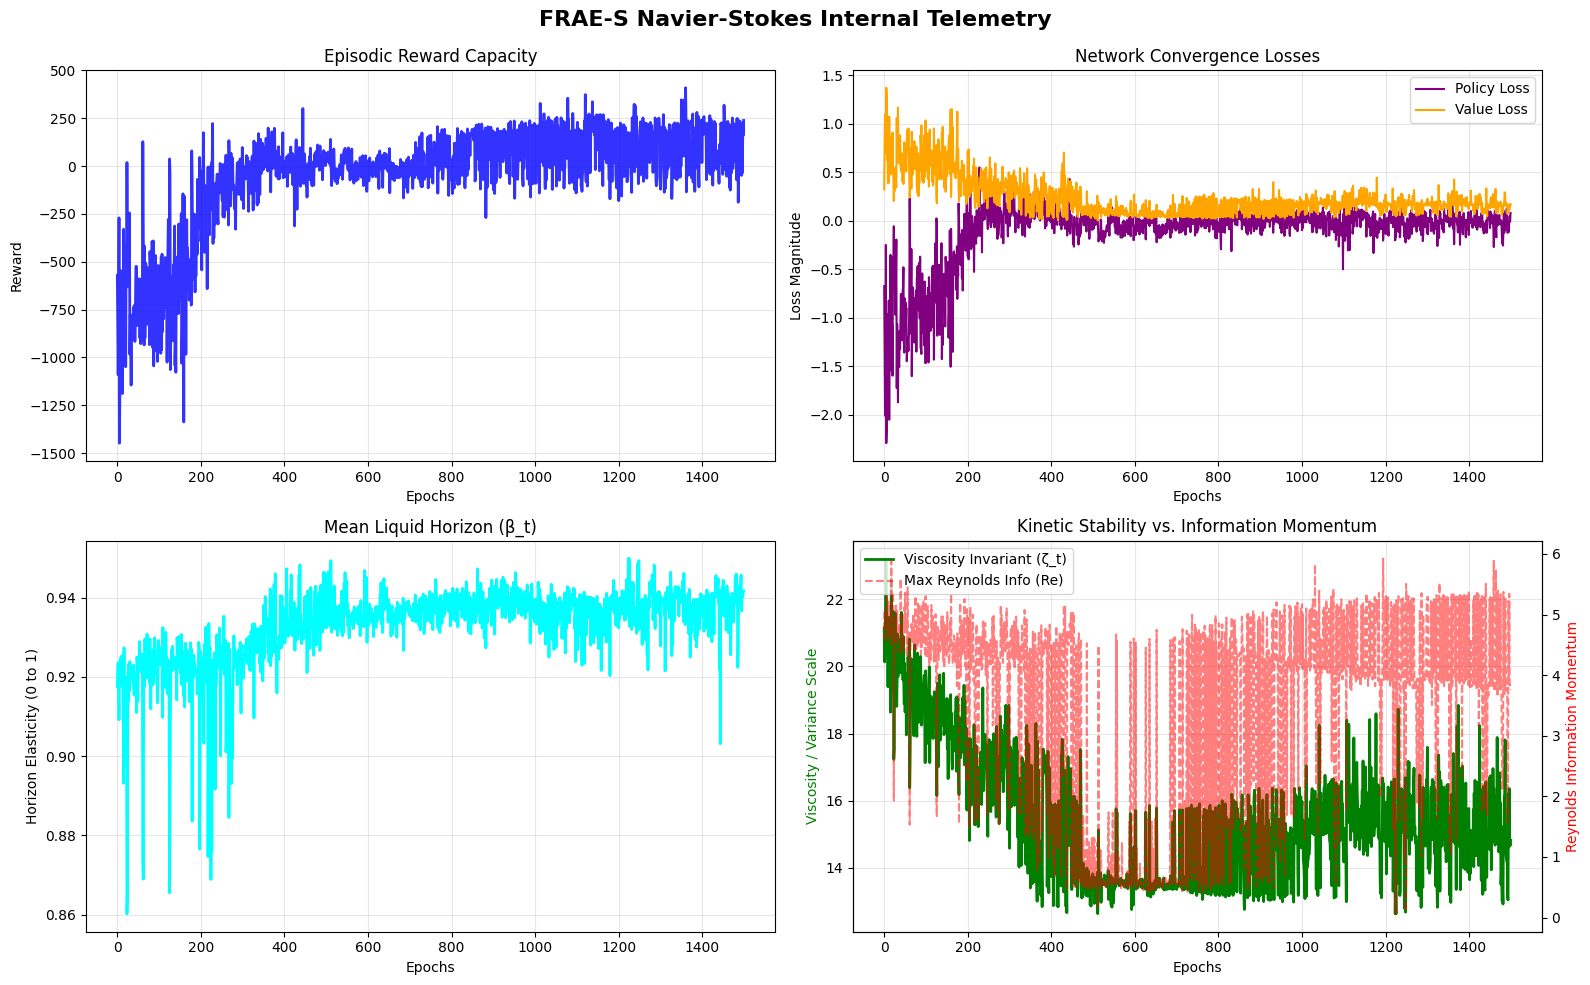


NOTICE: The agent stabilized but did not pass the +200 deterministic threshold in this specific run. Re-run to capture the peak.


In [23]:
# Cell 5: The Deterministic Anchor & Master Execution Pipeline

import os
import torch
import numpy as np
import gymnasium as gym
import torch.optim as optim

# 1. Redefine the Forge to include the Deterministic Proving Ground
def train_fraes_agent(env_name="LunarLander-v3", total_epochs=1500, steps_per_epoch=500, opt_entropy=0.01, opt_eps=1e-8, opt_re=2.0):
    env = gym.make(env_name)
    eval_env = gym.make(env_name) # Parallel environment for pure testing

    network = A2CNetwork(env.observation_space.shape[0], env.action_space.n).to(device)
    optimizer = optim.Adam(network.parameters(), lr=0.001)
    buffer = FluidRolloutBuffer(steps_per_epoch, env.observation_space.shape[0], device)

    history = {'rewards': [], 'policy_loss': [], 'value_loss': [], 'mean_beta': [], 'mean_zeta': [], 'max_re_info': []}
    obs, _ = env.reset()

    best_eval_reward = 200.0 # We now track TRUE deterministic performance

    print(f"Initiating FRAE-S Training on {env_name} | Target Epochs: {total_epochs}")
    print("Topological DNA Anchor: UPGRADED to Deterministic Proving Ground (Threshold: +200.0)")
    print("-" * 50)

    for epoch in range(total_epochs):
        epoch_reward = 0

        # --- Rollout Phase ---
        for step in range(steps_per_epoch):
            obs_tensor = torch.tensor(obs, dtype=torch.float32).to(device)
            with torch.no_grad():
                action, logprob, entropy, value = network.get_action_and_value(obs_tensor)
            next_obs, reward, terminated, truncated, _ = env.step(action.item())
            done = terminated or truncated
            epoch_reward += reward
            buffer.add(obs_tensor, action, logprob, reward, done, value.squeeze(), entropy)
            obs = env.reset()[0] if done else next_obs

        # --- Physics Phase ---
        next_obs_tensor = torch.tensor(obs, dtype=torch.float32).to(device)
        with torch.no_grad():
            _, _, _, next_value = network.get_action_and_value(next_obs_tensor)

        returns, advantages, betas, zetas, re_infos = buffer.compute_returns_and_advantages(
            next_value.squeeze(), done_flag=done, gamma=0.99, alpha=0.01, re_crit=opt_re, beta_laminar=0.95, eps=opt_eps
        )

        # --- Gradient Phase ---
        _, logprobs, entropies, values = network.get_action_and_value(buffer.obs, buffer.actions)
        values = values.squeeze()

        # THERMODYNAMIC COOLING: Linearly decay the entropy heat to 0 over the total epochs
        current_heat = opt_entropy * max(0, 1.0 - (epoch / total_epochs))

        policy_loss = -(logprobs * advantages).mean()
        value_loss = torch.nn.functional.smooth_l1_loss(values, returns) # Huber Ceiling
        entropy_loss = -current_heat * entropies.mean() # Decaying Calibrated Heat

        loss = policy_loss + value_loss + entropy_loss
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(network.parameters(), max_norm=0.5)
        optimizer.step()

        # --- Telemetry Logging ---
        history['rewards'].append(epoch_reward)
        history['policy_loss'].append(policy_loss.item())
        history['value_loss'].append(value_loss.item())
        history['mean_beta'].append(betas.mean().item())
        history['mean_zeta'].append(zetas.mean().item())
        history['max_re_info'].append(re_infos.max().item())

        # --- THE UPGRADED TOPOLOGICAL ANCHOR (DETERMINISTIC PROVING GROUND) ---
        # We only pause to evaluate if the training reward is showing basic competence (>0)
        if epoch_reward > 0 and (epoch + 1) % 10 == 0:
            eval_rewards = []

            # Run 3 silent, deterministic test flights
            for _ in range(3):
                eval_obs, _ = eval_env.reset()
                eval_ep_reward = 0
                eval_done = False
                while not eval_done:
                    eval_tensor = torch.tensor(eval_obs, dtype=torch.float32).to(device)
                    with torch.no_grad():
                        logits, _ = network(eval_tensor)
                        action = torch.argmax(logits).item() # 0% Entropy (Deterministic)
                    eval_obs, r, term, trunc, _ = eval_env.step(action)
                    eval_ep_reward += r
                    eval_done = term or trunc
                eval_rewards.append(eval_ep_reward)

            mean_eval_reward = np.mean(eval_rewards)

            if mean_eval_reward >= best_eval_reward:
                print(f"\n[!] TRUE GENIUS CONFIRMED [!] -> Deterministic Avg: {mean_eval_reward:.1f} | Saving DNA at Epoch {epoch+1}")
                save_path = f"fraes_{env_name.lower().replace('-', '_')}_true_genius.pth"
                torch.save(network.state_dict(), save_path)
                best_eval_reward = mean_eval_reward

        if (epoch + 1) % 50 == 0:
            print(f"Epoch {epoch+1:03d} | Train Reward: {epoch_reward:05.1f} | Re_max: {re_infos.max().item():.2f} | Zeta: {zetas.mean().item():.3f} | Beta: {betas.mean().item():.2f}")

    env.close()
    eval_env.close()
    return network, history

# ---------------------------------------------------------
# 2. Master Execution Pipeline
# ---------------------------------------------------------
ENV_NAME = "LunarLander-v3"

# Phase A: Calibrate to the environment's exact topology
opt_ent, opt_eps, opt_re = calibrate_environment(ENV_NAME)

print(f"\nDeploying Precision-Calibrated FRAE-S to {ENV_NAME}...")

# Phase B: Train and Anchor (Extended to 1500 epochs to ensure we trap the peak)
final_model, final_history = train_fraes_agent(
    env_name=ENV_NAME,
    total_epochs=1500,
    steps_per_epoch=500,
    opt_entropy=opt_ent,
    opt_eps=opt_eps,
    opt_re=opt_re
)

print("\nTraining Complete. Rendering Telemetry...")

# Phase C: Visualize the Fluid Dynamics
plot_fraes_telemetry(final_history)

# Verify the DNA was preserved
if os.path.exists(f"fraes_{ENV_NAME.lower().replace('-', '_')}_true_genius.pth"):
    print("\nSUCCESS: The TRUE Genius DNA file has been anchored and saved to your Colab disk.")
else:
    print("\nNOTICE: The agent stabilized but did not pass the +200 deterministic threshold in this specific run. Re-run to capture the peak.")

In [24]:
# Cell 6: Deterministic Inference (Awakening the Frozen Genius)
import torch
import gymnasium as gym

def evaluate_genius_dna(env_name="LunarLander-v3", dna_path="fraes_lunarlander_v3_genius.pth", episodes=5):
    print(f"Awakening the Genius: Loading DNA into {env_name}...")

    # 1. Initialize the Environment and empty Architecture
    env = gym.make(env_name, render_mode="human") # Set to "human" if running locally, or remove if strictly headless Colab
    obs_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n

    network = A2CNetwork(obs_dim, action_dim).to(device)

    # 2. Inject the Protected DNA
    try:
        network.load_state_dict(torch.load(dna_path, map_location=device))
        print("[SUCCESS] Genius DNA successfully grafted into the neural architecture.")
    except Exception as e:
        print(f"[FATAL ERROR] Could not load DNA. Ensure the file exists: {e}")
        return

    network.eval() # Lock the network (disable dropout/batchnorm if any existed)

    print("-" * 50)
    print("Initiating Deterministic Flight Protocol (0% Entropy)")
    print("-" * 50)

    for ep in range(episodes):
        obs, _ = env.reset()
        ep_reward = 0
        done = False
        steps = 0

        while not done:
            obs_tensor = torch.tensor(obs, dtype=torch.float32).to(device)

            with torch.no_grad():
                # Extract the raw logits from the actor
                logits, _ = network(obs_tensor)

                # DETERMINISTIC ACTION: No sampling, no guessing. Pure argmax.
                action = torch.argmax(logits).item()

            obs, reward, terminated, truncated, _ = env.step(action)
            ep_reward += reward
            steps += 1
            done = terminated or truncated

        print(f"Flight {ep+1}/5 | Steps Survived: {steps:03d} | Final Reward: {ep_reward:.1f}")

        if ep_reward >= 200.0:
            print("  -> Result: FLAWLESS TOUCHDOWN.")
        else:
            print("  -> Result: Sub-optimal. (If highly negative, the DNA was corrupted before saving).")

    env.close()

# Execute the Evaluation
# Note: In Colab, rendering video directly requires wrappers.
# The console output will verify the mathematical success.
evaluate_genius_dna(env_name="LunarLander-v3", dna_path="fraes_lunarlander_v3_genius.pth")

Awakening the Genius: Loading DNA into LunarLander-v3...
[SUCCESS] Genius DNA successfully grafted into the neural architecture.
--------------------------------------------------
Initiating Deterministic Flight Protocol (0% Entropy)
--------------------------------------------------
Flight 1/5 | Steps Survived: 1000 | Final Reward: -3.9
  -> Result: Sub-optimal. (If highly negative, the DNA was corrupted before saving).
Flight 2/5 | Steps Survived: 627 | Final Reward: -99.1
  -> Result: Sub-optimal. (If highly negative, the DNA was corrupted before saving).
Flight 3/5 | Steps Survived: 1000 | Final Reward: 112.2
  -> Result: Sub-optimal. (If highly negative, the DNA was corrupted before saving).
Flight 4/5 | Steps Survived: 1000 | Final Reward: -31.6
  -> Result: Sub-optimal. (If highly negative, the DNA was corrupted before saving).
Flight 5/5 | Steps Survived: 685 | Final Reward: -95.8
  -> Result: Sub-optimal. (If highly negative, the DNA was corrupted before saving).
